# 🚆 LSTM Project: Next Word Prediction Model

<div style="padding:14px; border-radius:10px; background-color:#f3f7ff; border-left:6px solid #3b82f6; color: #000000;">
<b>Project Goal:</b> In this notebook, we build a simple <b>Next Word Prediction Model</b> using an <b>LSTM neural network</b> in PyTorch.
<br><br>
The model learns from a short story and predicts the next word based on the words given before it.
</div>

---

## ✅ What we will learn

By the end of this notebook, we will understand:

1. How text is converted into tokens.
2. How a vocabulary is created.
3. How training sequences are prepared for next-word prediction.
4. How padding makes all sequences equal in length.
5. How to build a PyTorch `Dataset` and `DataLoader`.
6. How an LSTM model works for text prediction.
7. How to train, test, and generate text from the model.

---

## 🧠 Simple idea of next-word prediction

If our sentence is:

> Daniel checked the ticket

The model learns examples like:

| Input words | Target next word |
|---|---|
| Daniel | checked |
| Daniel checked | the |
| Daniel checked the | ticket |

So, the model learns word patterns step by step.

# 1. ⚙️ Setup and Library Imports

We first import the required libraries.

### Why these libraries are needed

| Library | Purpose |
|---|---|
| `re` | Simple text tokenization using regular expressions |
| `torch` | Building and training the neural network |
| `numpy` | Numerical operations |
| `Counter` | Counting word frequencies |
| `Dataset`, `DataLoader` | Preparing batches for training |
| `matplotlib` | Plotting training loss |

> Note: This notebook uses a simple custom tokenizer, so it does not depend on external NLTK downloads.

In [1]:
# PyTorch libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Text processing and utility libraries
import re
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt

# Limit CPU threads to keep training stable and fast on most computers.
torch.set_num_threads(1)

# For reproducible results.
# This helps us get similar training results every time we run the notebook.
torch.manual_seed(42)
np.random.seed(42)

# Select GPU if available, otherwise use CPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


# 2. 📄 Dataset

For this project, we use a short story named **“The Last Train Journey”** as our training text.

Because the dataset is small, the model is mainly for learning the process.  
For a stronger real-world model, we need a much larger text dataset.

In [2]:
# Our training document.
# The model will learn word patterns from this story.
document = 'The Last Train Journey\n\nOn a cold winter evening, Daniel arrived at the old railway station carrying a small leather bag.\nThe station was nearly empty except for a few passengers waiting quietly on wooden benches.\nA loud whistle echoed through the air as the final train of the night slowly entered the platform.\n\nDaniel checked the ticket in his pocket and walked toward the train.\nThe metal doors opened with a creaking sound and warm air rushed outside.\nInside the train, yellow lights flickered softly above rows of empty seats.\n\nHe chose a seat beside the window and placed his bag carefully near his feet.\nAs the train began to move, the city lights slowly disappeared behind thick clouds of fog.\nSnow started falling gently outside while distant mountains appeared under the moonlight.\n\nAcross the aisle sat an elderly woman reading an old book with a blue cover.\nEvery few minutes she looked outside the window as if searching for something familiar.\nDaniel noticed a silver necklace around her neck shaped like a small compass.\n\nAfter several hours, the train stopped at a remote station surrounded by tall pine trees.\nVery few people entered or left the train at that place.\nA strange silence covered the station as the doors closed once again.\n\nCurious about the woman, Daniel finally started a conversation.\nThe woman introduced herself as Eleanor and explained that she was returning to her hometown after many years.\nShe said the town was hidden deep within the northern mountains and was known for its beautiful frozen lake.\n\nAs the journey continued, Eleanor shared stories from her childhood.\nShe described colorful festivals, music performances, and lanterns floating across the lake during winter nights.\nDaniel listened carefully while the train moved through snowy valleys and dark forests.\n\nNear midnight, the train suddenly slowed down because heavy snow had covered the tracks ahead.\nPassengers became nervous and began discussing possible delays.\nConductors moved through the cabins trying to calm everyone.\n\nDaniel looked outside and saw workers removing snow under bright floodlights.\nThe freezing wind shook the train slightly while snow continued falling from the dark sky.\nDespite the delay, Eleanor remained calm and continued telling her stories.\n\nSeveral hours later, the tracks were finally cleared and the train resumed its journey.\nThe passengers sighed with relief as warm coffee was served throughout the cabins.\nDaniel and Eleanor continued talking about travel, history, and forgotten places around the world.\n\nJust before sunrise, the train reached the mountain town.\nThe station was small but beautifully decorated with glowing lamps and snow-covered rooftops.\nPeople wearing thick winter coats walked slowly across the icy streets.\n\nBefore leaving, Eleanor handed Daniel a folded piece of paper.\nInside it was a drawing of the frozen lake along with a short message thanking him for the conversation.\nDaniel smiled and carefully placed the paper inside his notebook.\n\nAs the train departed once again, Daniel stood on the platform watching the sunrise over the mountains.\nThe cold air, quiet streets, and distant church bells created a peaceful atmosphere he would never forget.\nYears later, Daniel would still remember that mysterious winter journey and the stories shared by Eleanor on the last train of the night.\n'

print("Total characters in document:", len(document))
print("\nPreview of the document:\n")
print(document[:600])

Total characters in document: 3360

Preview of the document:

The Last Train Journey

On a cold winter evening, Daniel arrived at the old railway station carrying a small leather bag.
The station was nearly empty except for a few passengers waiting quietly on wooden benches.
A loud whistle echoed through the air as the final train of the night slowly entered the platform.

Daniel checked the ticket in his pocket and walked toward the train.
The metal doors opened with a creaking sound and warm air rushed outside.
Inside the train, yellow lights flickered softly above rows of empty seats.

He chose a seat beside the window and placed his bag carefully nea


# 3. ✂️ Text Tokenization

Tokenization means splitting text into smaller units called **tokens**.

For this project, each word and punctuation mark becomes a token.

Example:

```text
"The train arrived."
```

After tokenization:

```text
["the", "train", "arrived", "."]
```

We also convert all text to lowercase so that `The` and `the` are treated as the same word.

In [3]:
def simple_tokenize(text):
    """
    Convert text into lowercase tokens.

    This tokenizer keeps:
    - words, such as "train"
    - numbers, such as "12"
    - punctuation, such as "." and ","

    Example:
    "The train arrived." -> ["the", "train", "arrived", "."]
    """
    text = text.lower()

    # \\b\\w+\\b finds words/numbers.
    # [^\\w\\s] finds punctuation marks.
    tokens = re.findall(r"\b\w+\b|[^\w\s]", text)

    return tokens


# Tokenize the whole document.
tokens = simple_tokenize(document)

print("Total tokens:", len(tokens))
print("First 40 tokens:")
print(tokens[:40])

Total tokens: 597
First 40 tokens:
['the', 'last', 'train', 'journey', 'on', 'a', 'cold', 'winter', 'evening', ',', 'daniel', 'arrived', 'at', 'the', 'old', 'railway', 'station', 'carrying', 'a', 'small', 'leather', 'bag', '.', 'the', 'station', 'was', 'nearly', 'empty', 'except', 'for', 'a', 'few', 'passengers', 'waiting', 'quietly', 'on', 'wooden', 'benches', '.', 'a']


# 4. 📚 Vocabulary Building

A vocabulary is a dictionary that maps each unique token to a unique number.

Neural networks cannot directly understand words.  
So, we convert words into numbers.

We use two special tokens:

| Token | Meaning |
|---|---|
| `<pad>` | Used to fill empty positions during padding |
| `<unk>` | Used for unknown words that are not in the vocabulary |

In [4]:
# Count how many times each token appears.
token_counts = Counter(tokens)

# Create vocabulary.
# <pad> gets index 0 because we will use it for padding.
# <unk> gets index 1 for unknown words.
vocab = {
    "<pad>": 0,
    "<unk>": 1
}

# Add each unique token to the vocabulary.
for token in token_counts.keys():
    if token not in vocab:
        vocab[token] = len(vocab)

# Reverse vocabulary: index -> word.
# This helps us convert predicted numbers back into words.
index_to_word = {index: word for word, index in vocab.items()}

print("Vocabulary size:", len(vocab))
print("\nFirst 20 vocabulary items:")
for word, index in list(vocab.items())[:20]:
    print(f"{word:15s} -> {index}")

Vocabulary size: 285

First 20 vocabulary items:
<pad>           -> 0
<unk>           -> 1
the             -> 2
last            -> 3
train           -> 4
journey         -> 5
on              -> 6
a               -> 7
cold            -> 8
winter          -> 9
evening         -> 10
,               -> 11
daniel          -> 12
arrived         -> 13
at              -> 14
old             -> 15
railway         -> 16
station         -> 17
carrying        -> 18
small           -> 19


# 5. 🔢 Converting Text into Numbers

Now we create a helper function that converts a sentence into numerical indices.

Example:

```text
"the train"
```

may become:

```text
[2, 15]
```

The exact numbers depend on our vocabulary.

In [5]:
def text_to_indices(tokenized_sentence, vocab):
    """
    Convert a list of tokens into a list of numerical indices.

    Parameters:
    tokenized_sentence: list of words/tokens
    vocab: dictionary where key = token and value = index

    Returns:
    numerical_sentence: list of integer indices
    """
    numerical_sentence = []

    for token in tokenized_sentence:
        # If the token exists in vocabulary, use its index.
        if token in vocab:
            numerical_sentence.append(vocab[token])

        # If the token is not found, use <unk> index.
        else:
            numerical_sentence.append(vocab["<unk>"])

    return numerical_sentence


# Test the function with a small sentence.
sample_sentence = "Daniel checked the ticket"
sample_tokens = simple_tokenize(sample_sentence)
sample_indices = text_to_indices(sample_tokens, vocab)

print("Sample tokens:", sample_tokens)
print("Sample indices:", sample_indices)

Sample tokens: ['daniel', 'checked', 'the', 'ticket']
Sample indices: [12, 46, 2, 47]


# 6. 🧩 Preparing Training Sequences

For next-word prediction, we create many small training examples from each sentence.

Example sentence:

```text
Daniel checked the ticket
```

Training sequences:

```text
Daniel checked
Daniel checked the
Daniel checked the ticket
```

For each sequence:

- All words except the last word become the **input**.
- The last word becomes the **target/output**.

In [6]:
# Split the document into lines.
# Empty lines are removed because they do not provide useful training examples.
sentences = [line.strip() for line in document.split("\n") if line.strip()]

print("Total sentences/lines:", len(sentences))
print("\nExample sentence:")
print(sentences[1])

Total sentences/lines: 40

Example sentence:
On a cold winter evening, Daniel arrived at the old railway station carrying a small leather bag.


In [7]:
# Convert each sentence into numerical form.
numerical_sentences = []

for sentence in sentences:
    # Tokenize each sentence.
    sentence_tokens = simple_tokenize(sentence)

    # Convert tokens to indices.
    sentence_indices = text_to_indices(sentence_tokens, vocab)

    # Save the numerical sentence.
    numerical_sentences.append(sentence_indices)

print("First numerical sentence:")
print(numerical_sentences[0])

First numerical sentence:
[2, 3, 4, 5]


In [8]:
# Create training sequences.
# Each sequence contains at least two words:
# input part + target next word.
training_sequences = []

for sentence in numerical_sentences:
    for i in range(1, len(sentence)):
        # sentence[:i+1] means we take words from the start up to the current word.
        training_sequences.append(sentence[:i + 1])

print("Total training sequences:", len(training_sequences))
print("\nFirst 5 training sequences:")
for seq in training_sequences[:5]:
    print(seq)

Total training sequences: 557

First 5 training sequences:
[2, 3]
[2, 3, 4]
[2, 3, 4, 5]
[6, 7]
[6, 7, 8]


# 7. 📏 Padding Sequences

LSTM models process batches of equal-length sequences.

But our training sequences have different lengths.

So, we add `<pad>` tokens at the beginning of shorter sequences.

Example:

```text
[Daniel, checked]
```

may become:

```text
[<pad>, <pad>, Daniel, checked]
```

We use **left padding** because the most recent words should stay near the end of the sequence.

In [9]:
# Find the length of the longest training sequence.
max_sequence_length = max(len(sequence) for sequence in training_sequences)

print("Maximum sequence length:", max_sequence_length)

Maximum sequence length: 25


In [10]:
# Pad all sequences to the same length.
padded_sequences = []

for sequence in training_sequences:
    # Number of padding tokens needed.
    padding_needed = max_sequence_length - len(sequence)

    # Add <pad> tokens to the beginning.
    padded_sequence = [vocab["<pad>"]] * padding_needed + sequence

    padded_sequences.append(padded_sequence)

# Convert the padded list into a PyTorch tensor.
padded_sequences = torch.tensor(padded_sequences, dtype=torch.long)

print("Shape of padded sequences:", padded_sequences.shape)
print("\nFirst padded sequence:")
print(padded_sequences[0])

Shape of padded sequences: torch.Size([557, 25])

First padded sequence:
tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2,
        3])


# 8. 🎯 Creating Input `X` and Target `y`

Each padded sequence contains:

- The first part: input words
- The last word: target word

So we split like this:

```text
[<pad>, <pad>, Daniel, checked]
```

Input `X`:

```text
[<pad>, <pad>, Daniel]
```

Target `y`:

```text
checked
```

In [11]:
# X contains all words except the last word.
X = padded_sequences[:, :-1]

# y contains only the last word.
y = padded_sequences[:, -1]

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

print("\nFirst input sequence X[0]:")
print(X[0])

print("\nFirst target y[0]:")
print(y[0], "->", index_to_word[int(y[0])])

Shape of X: torch.Size([557, 24])
Shape of y: torch.Size([557])

First input sequence X[0]:
tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2])

First target y[0]:
tensor(3) -> last


# 9. 📦 Custom Dataset and DataLoader

PyTorch uses a `Dataset` to store samples and a `DataLoader` to load them in batches.

### Why batching is useful

Instead of training with one example at a time, we train with a batch of examples together.  
This makes training faster and more stable.

In [12]:
class NextWordDataset(Dataset):
    """
    Custom PyTorch Dataset for next-word prediction.

    Each item contains:
    - X[index]: input sequence
    - y[index]: target next word
    """

    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        # Return total number of training examples.
        return len(self.X)

    def __getitem__(self, index):
        # Return one input-target pair.
        return self.X[index], self.y[index]


# Create dataset object.
dataset = NextWordDataset(X, y)

# Create DataLoader object.
# shuffle=True means data order changes in every epoch.
batch_size = 32
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

print("Total samples in dataset:", len(dataset))
print("Batch size:", batch_size)

Total samples in dataset: 557
Batch size: 32


In [13]:
# Check one batch to understand the shape.
batch_X, batch_y = next(iter(dataloader))

print("Input batch shape:", batch_X.shape)
print("Target batch shape:", batch_y.shape)

Input batch shape: torch.Size([32, 24])
Target batch shape: torch.Size([32])


# 10. 🧠 LSTM Model Architecture

We now build the LSTM model.

### Model flow

```text
Input word indices
        ↓
Embedding layer
        ↓
LSTM layer
        ↓
Fully connected layer
        ↓
Predicted next word
```

### Layer explanation

| Layer | Job |
|---|---|
| `Embedding` | Converts word indices into dense vectors |
| `LSTM` | Learns sequence patterns and word order |
| `Linear` | Converts LSTM output into vocabulary-size prediction |

In [14]:
class LSTMNextWordModel(nn.Module):
    """
    LSTM model for next-word prediction.
    """

    def __init__(self, vocab_size, embedding_dim=32, hidden_dim=64):
        super().__init__()

        # Embedding layer:
        # Converts each word index into a vector of size embedding_dim.
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=vocab["<pad>"]
        )

        # LSTM layer:
        # Reads the sequence and learns the context.
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            batch_first=True
        )

        # Fully connected layer:
        # Converts hidden state into scores for every word in the vocabulary.
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x):
        # x shape: [batch_size, sequence_length]

        # Convert word indices to embeddings.
        embedded = self.embedding(x)
        # embedded shape: [batch_size, sequence_length, embedding_dim]

        # Pass embeddings through LSTM.
        lstm_output, (hidden_state, cell_state) = self.lstm(embedded)

        # hidden_state shape: [num_layers, batch_size, hidden_dim]
        # Since we use one LSTM layer, we take hidden_state[-1].
        final_hidden_state = hidden_state[-1]

        # Predict next word scores.
        output = self.fc(final_hidden_state)

        return output


# Create model object.
model = LSTMNextWordModel(vocab_size=len(vocab)).to(device)

print(model)

LSTMNextWordModel(
  (embedding): Embedding(285, 32, padding_idx=0)
  (lstm): LSTM(32, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=285, bias=True)
)


# 11. 🏋️ Training the Model

During training:

1. We send input sequences to the model.
2. The model predicts the next word.
3. We compare prediction with the actual target word.
4. We calculate the loss.
5. We update the model weights using backpropagation.

We use a small model so the notebook can run faster in Google Colab or on a normal laptop.

| Item | Choice |
|---|---|
| Loss function | `CrossEntropyLoss` |
| Optimizer | `Adam` |
| Epochs | `20` |
| Learning rate | `0.001` |

In [15]:
# Training settings
epochs = 20
learning_rate = 0.001

# CrossEntropyLoss is commonly used for multi-class classification.
# Here, every word in the vocabulary is a class.
criterion = nn.CrossEntropyLoss()

# Adam optimizer updates model weights.
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Store loss values so that we can plot them later.
loss_history = []

# Put model in training mode.
model.train()

for epoch in range(epochs):
    total_loss = 0

    for batch_X, batch_y in dataloader:
        # Move data to CPU/GPU.
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        # Clear old gradients.
        optimizer.zero_grad()

        # Forward pass: get predictions.
        outputs = model(batch_X)

        # Calculate loss.
        loss = criterion(outputs, batch_y)

        # Backward pass: calculate gradients.
        loss.backward()

        # Update model weights.
        optimizer.step()

        # Add batch loss.
        total_loss += loss.item()

    # Average loss for this epoch.
    average_loss = total_loss / len(dataloader)
    loss_history.append(average_loss)

    # Print progress every 5 epochs and also on the first epoch.
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch + 1:02d}/{epochs}], Loss: {average_loss:.4f}")

Epoch [01/20], Loss: 5.6457
Epoch [05/20], Loss: 4.9412
Epoch [10/20], Loss: 4.4844
Epoch [15/20], Loss: 3.9670
Epoch [20/20], Loss: 3.4898


# 12. 📉 Visualizing Training Loss

A decreasing loss usually means the model is learning.

Because this is a small dataset, the model may memorize the training text.  
That is normal for a beginner-level next-word prediction project.

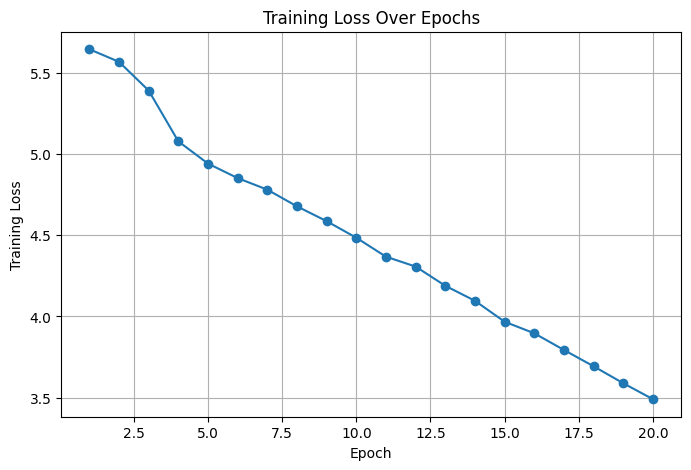

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), loss_history, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Over Epochs")
plt.grid(True)
plt.show()

# 13. 🔮 Predicting the Next Word

Now we create a function that predicts one next word.

Important steps:

1. Tokenize the input text.
2. Convert tokens into indices.
3. Pad the sequence.
4. Send it to the model.
5. Select the word with the highest predicted score.

In [17]:
def predict_next_word(model, text, vocab, index_to_word, max_input_length):
    """
    Predict the next word for a given input text.

    Parameters:
    model: trained LSTM model
    text: input sentence as a string
    vocab: word-to-index dictionary
    index_to_word: index-to-word dictionary
    max_input_length: fixed input length expected by the model

    Returns:
    predicted_word: next predicted word
    """

    # Put model in evaluation mode.
    model.eval()

    # Tokenize input text.
    tokens = simple_tokenize(text)

    # Convert tokens to numerical indices.
    numerical_text = text_to_indices(tokens, vocab)

    # If the input is too long, keep only the last max_input_length tokens.
    numerical_text = numerical_text[-max_input_length:]

    # Add left padding if input is shorter than max_input_length.
    padding_needed = max_input_length - len(numerical_text)
    padded_text = [vocab["<pad>"]] * padding_needed + numerical_text

    # Convert to tensor and add batch dimension.
    input_tensor = torch.tensor(padded_text, dtype=torch.long).unsqueeze(0).to(device)

    # We do not need gradients during prediction.
    with torch.no_grad():
        output = model(input_tensor)

        # Get the index with the highest score.
        predicted_index = torch.argmax(output, dim=1).item()

    # Convert predicted index back to word.
    predicted_word = index_to_word[predicted_index]

    return predicted_word

In [18]:
# The model input length is one less than the full padded sequence length.
max_input_length = max_sequence_length - 1

test_text = "Daniel checked the ticket"
next_word = predict_next_word(model, test_text, vocab, index_to_word, max_input_length)

print("Input text:", test_text)
print("Predicted next word:", next_word)
print("Full output:", test_text + " " + next_word)

Input text: Daniel checked the ticket
Predicted next word: .
Full output: Daniel checked the ticket .


# 14. ✍️ Generating Multiple Words

We can repeatedly predict one word and add it to the text.

This creates a short generated sentence.

In [19]:
def generate_text(model, starting_text, num_words, vocab, index_to_word, max_input_length):
    """
    Generate multiple words using the trained model.

    Parameters:
    starting_text: initial text given by us
    num_words: number of new words to generate

    Returns:
    generated_text: final generated text
    """

    generated_text = starting_text

    for _ in range(num_words):
        # Predict next word.
        next_word = predict_next_word(
            model,
            generated_text,
            vocab,
            index_to_word,
            max_input_length
        )

        # Add predicted word to the current text.
        generated_text = generated_text + " " + next_word

    return generated_text


starting_text = "Daniel checked the ticket"
generated_output = generate_text(
    model=model,
    starting_text=starting_text,
    num_words=20,
    vocab=vocab,
    index_to_word=index_to_word,
    max_input_length=max_input_length
)

print(generated_output)

Daniel checked the ticket . . and a for . . . the train , and the train train the train . . .


# 15. ✅ Training Accuracy

Accuracy tells us how many next words the model predicts correctly on the training data.

⚠️ Important: This is **training accuracy**, not real test accuracy.  
Since our dataset is small, high training accuracy may mean the model memorized the story.

In [20]:
def calculate_accuracy(model, dataloader, device):
    """
    Calculate accuracy on the given dataloader.
    """

    # Evaluation mode.
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for batch_X, batch_y in dataloader:
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)

            # Get predictions.
            outputs = model(batch_X)

            # Choose word index with highest score.
            predicted = torch.argmax(outputs, dim=1)

            # Count correct predictions.
            correct += (predicted == batch_y).sum().item()
            total += batch_y.size(0)

    accuracy = (correct / total) * 100
    return accuracy


training_accuracy = calculate_accuracy(model, dataloader, device)
print(f"Training Accuracy: {training_accuracy:.2f}%")

Training Accuracy: 21.72%
